In this project, we analyze a dataset to predict whether a loan application will be accepted or rejected using the **Random Forest Classifier** .  
We will go through data exploration 🔍, preprocessing 🧹, model training , evaluation 🧪, and visualization 📈.


# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pickle





# Load the Data

In [2]:
df=pd.read_csv("/kaggle/input/loan-approval-classification-data/loan_data.csv")

In [3]:
df

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,27.0,male,Associate,47971.0,6,RENT,15000.0,MEDICAL,15.66,0.31,3.0,645,No,1
44996,37.0,female,Associate,65800.0,17,RENT,9000.0,HOMEIMPROVEMENT,14.07,0.14,11.0,621,No,1
44997,33.0,male,Associate,56942.0,7,RENT,2771.0,DEBTCONSOLIDATION,10.02,0.05,10.0,668,No,1
44998,29.0,male,Bachelor,33164.0,4,RENT,12000.0,EDUCATION,13.23,0.36,6.0,604,No,1


# Exploratory Data Analysis (EDA)

In [4]:
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [5]:
df.columns

Index(['person_age', 'person_gender', 'person_education', 'person_income',
       'person_emp_exp', 'person_home_ownership', 'loan_amnt', 'loan_intent',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'credit_score', 'previous_loan_defaults_on_file', 'loan_status'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

In [7]:
df.describe()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756,0.222222
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000


In [8]:
df.isnull().sum().sort_values(ascending=False)

person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64

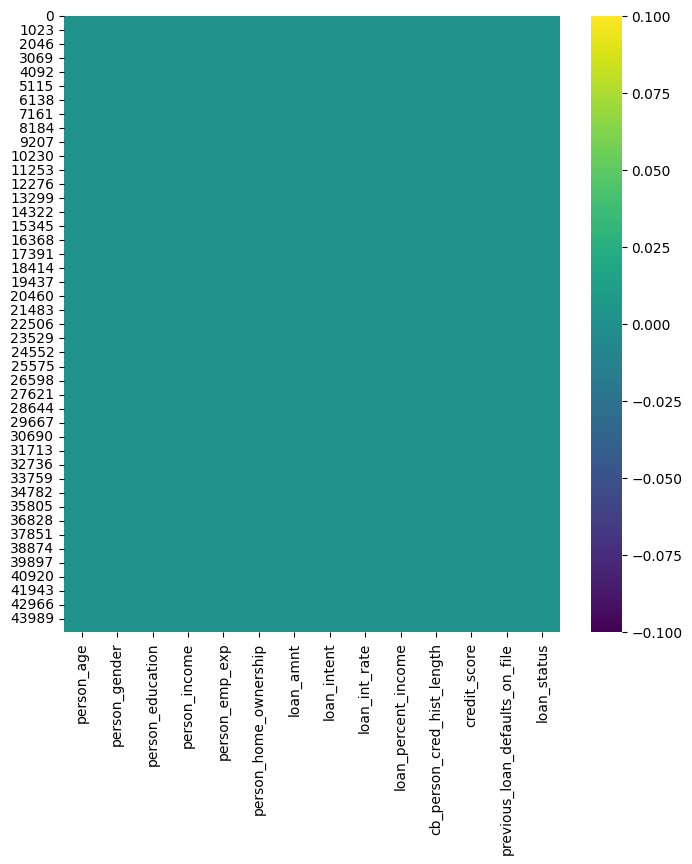

In [9]:
plt.figure(figsize=(8,8))
sns.heatmap(df.isnull(),cmap='viridis')
plt.show()

In [10]:
gender_counts = df['person_gender'].value_counts()
gender_counts

person_gender
male      24841
female    20159
Name: count, dtype: int64

# Visualization

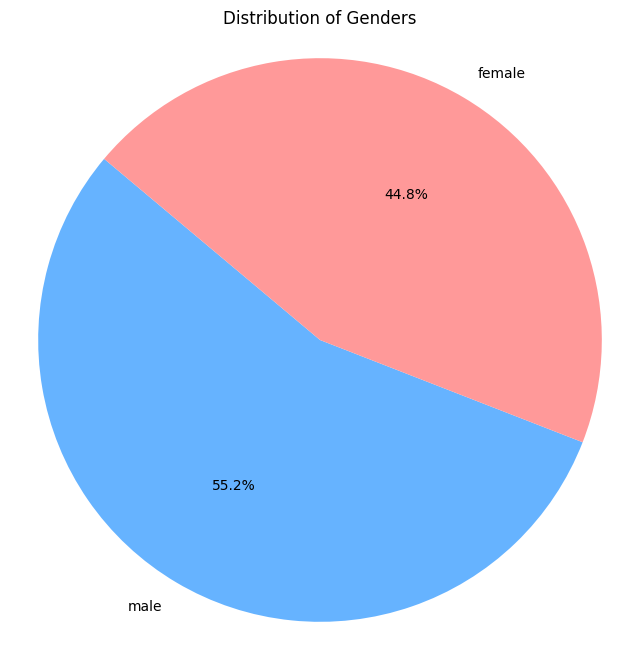

In [11]:
plt.figure(figsize=(8,8))
plt.pie(gender_counts,labels=gender_counts.index,autopct='%1.1f%%', startangle=140, colors=['#66b3ff','#ff9999'])
plt.title('Distribution of Genders')
plt.axis('equal')
plt.show()


In [12]:
df.groupby('loan_status')['loan_amnt'].mean()


loan_status
0     9219.576914
1    10855.689800
Name: loan_amnt, dtype: float64

In [13]:
df.groupby('loan_status')['loan_amnt'].median()


loan_status
0    8000.0
1    9750.0
Name: loan_amnt, dtype: float64

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


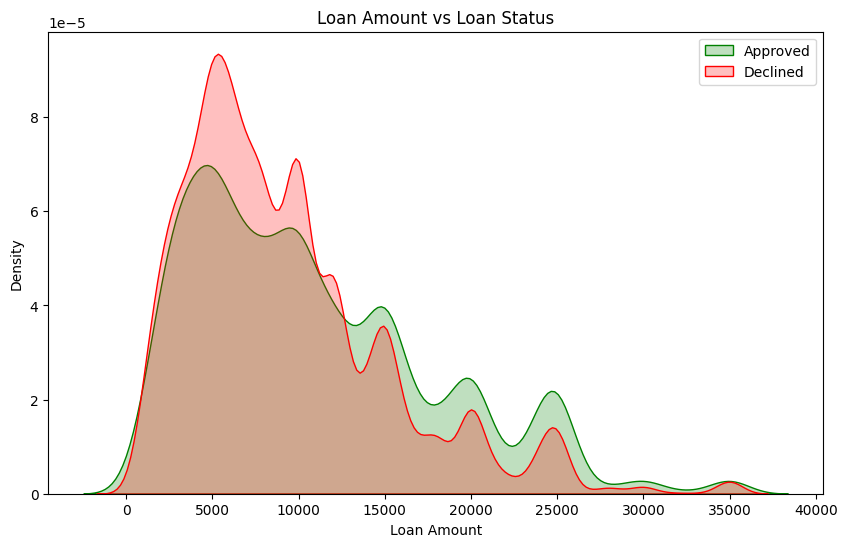

In [14]:
plt.figure(figsize=(10,6))
sns.kdeplot(data=df[df['loan_status'] == 1], x='loan_amnt', label='Approved', fill=True, color='green')
sns.kdeplot(data=df[df['loan_status'] == 0], x='loan_amnt', label='Declined', fill=True, color='red')
plt.title('Loan Amount vs Loan Status')
plt.xlabel('Loan Amount')
plt.ylabel('Density')
plt.legend()
plt.show()

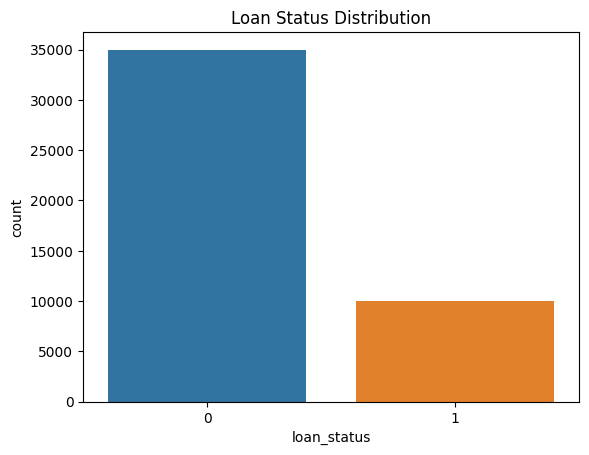

In [15]:
sns.countplot(x='loan_status', data=df)
plt.title('Loan Status Distribution')
plt.show()

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

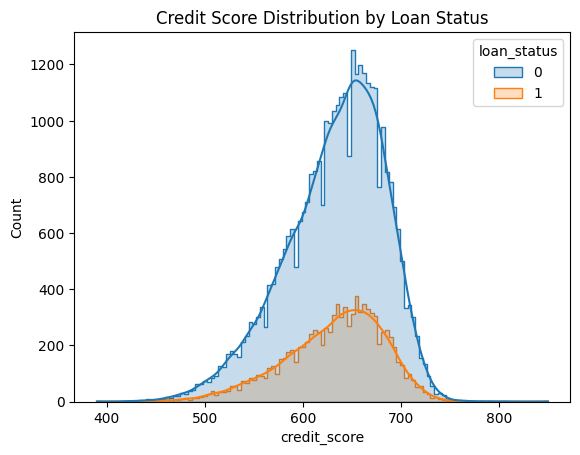

In [16]:
sns.histplot(data=df, x='credit_score', hue='loan_status', kde=True, element="step")
plt.title('Credit Score Distribution by Loan Status')
plt.show()


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


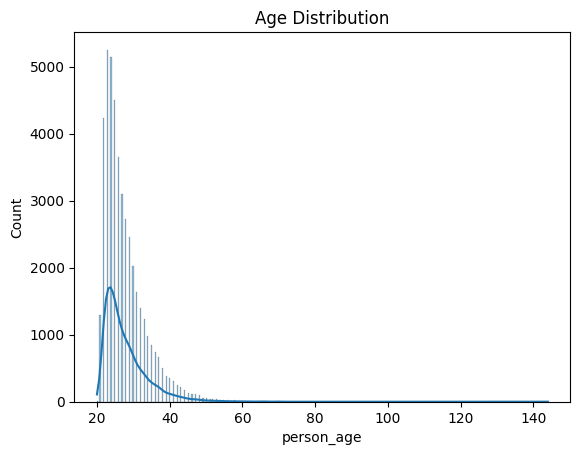

In [17]:
sns.histplot(df['person_age'], kde=True)
plt.title('Age Distribution')
plt.show()


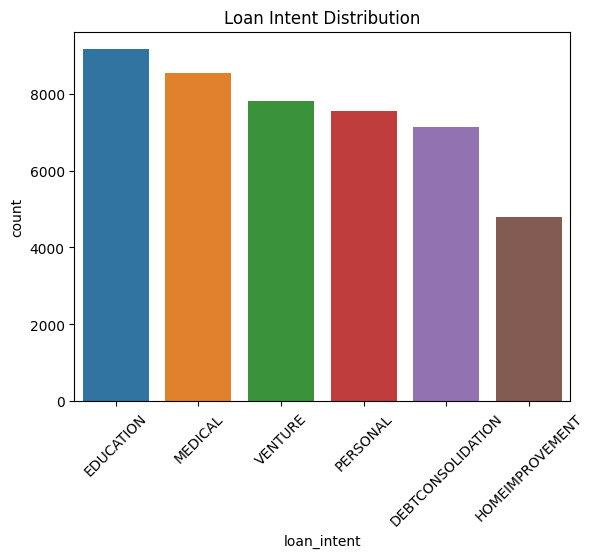

In [18]:
sns.countplot(data=df, x='loan_intent', order=df['loan_intent'].value_counts().index)
plt.title('Loan Intent Distribution')
plt.xticks(rotation=45)
plt.show()


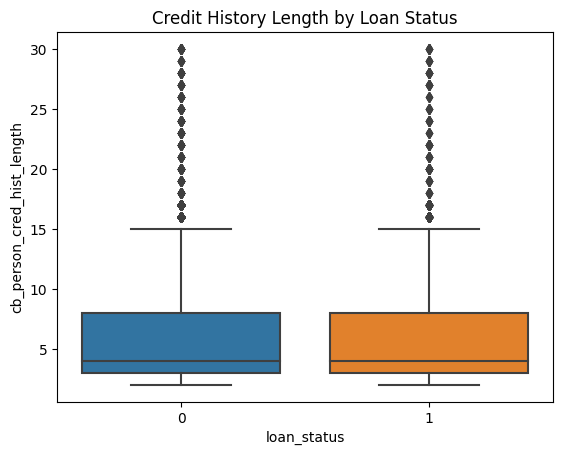

In [19]:
sns.boxplot(x='loan_status', y='cb_person_cred_hist_length', data=df)
plt.title('Credit History Length by Loan Status')
plt.show()


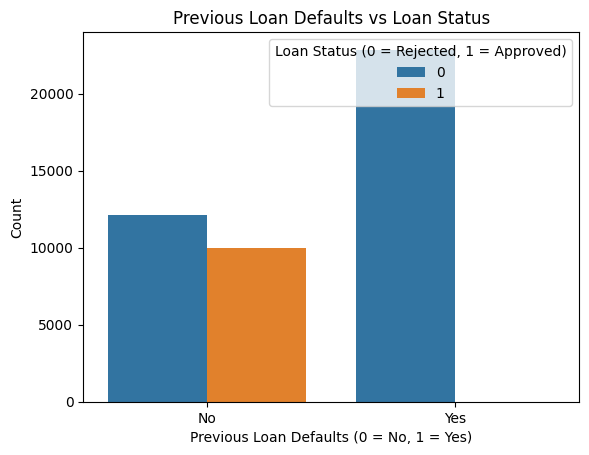

In [20]:
sns.countplot(data=df, x='previous_loan_defaults_on_file', hue='loan_status')
plt.title('Previous Loan Defaults vs Loan Status')
plt.xlabel('Previous Loan Defaults (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.legend(title='Loan Status (0 = Rejected, 1 = Approved)')
plt.show()


In [21]:
pd.crosstab(df['previous_loan_defaults_on_file'], df['loan_status'], normalize='index') * 100


loan_status,0,1
previous_loan_defaults_on_file,,
No,54.836961,45.163039
Yes,100.000000,0.000000


# Data Preprocessing

In [22]:
le = LabelEncoder()
df['person_gender'] = le.fit_transform(df['person_gender'])
df['previous_loan_defaults_on_file'] = le.fit_transform(df['previous_loan_defaults_on_file'])


In [23]:
df = pd.get_dummies(df, columns=['person_education', 'person_home_ownership', 'loan_intent'], drop_first=True,dtype=int)


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 23 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  int64  
 2   person_income                   45000 non-null  float64
 3   person_emp_exp                  45000 non-null  int64  
 4   loan_amnt                       45000 non-null  float64
 5   loan_int_rate                   45000 non-null  float64
 6   loan_percent_income             45000 non-null  float64
 7   cb_person_cred_hist_length      45000 non-null  float64
 8   credit_score                    45000 non-null  int64  
 9   previous_loan_defaults_on_file  45000 non-null  int64  
 10  loan_status                     45000 non-null  int64  
 11  person_education_Bachelor       45000 non-null  int64  
 12  person_education_Doctorate      

In [25]:
correlation_matrix = df.corr()
print(correlation_matrix['loan_status'].sort_values(ascending=False))

loan_status                       1.000000
loan_percent_income               0.384880
loan_int_rate                     0.332005
person_home_ownership_RENT        0.255239
loan_amnt                         0.107714
loan_intent_MEDICAL               0.065195
loan_intent_HOMEIMPROVEMENT       0.033838
person_home_ownership_OTHER       0.013645
person_education_Bachelor         0.004728
person_education_Doctorate        0.001833
person_education_High School      0.001277
person_gender                    -0.000561
person_education_Master          -0.004741
credit_score                     -0.007647
cb_person_cred_hist_length       -0.014851
person_emp_exp                   -0.020481
person_age                       -0.021476
loan_intent_PERSONAL             -0.022488
loan_intent_EDUCATION            -0.064006
loan_intent_VENTURE              -0.085992
person_home_ownership_OWN        -0.093666
person_income                    -0.135808
previous_loan_defaults_on_file   -0.543096
Name: loan_

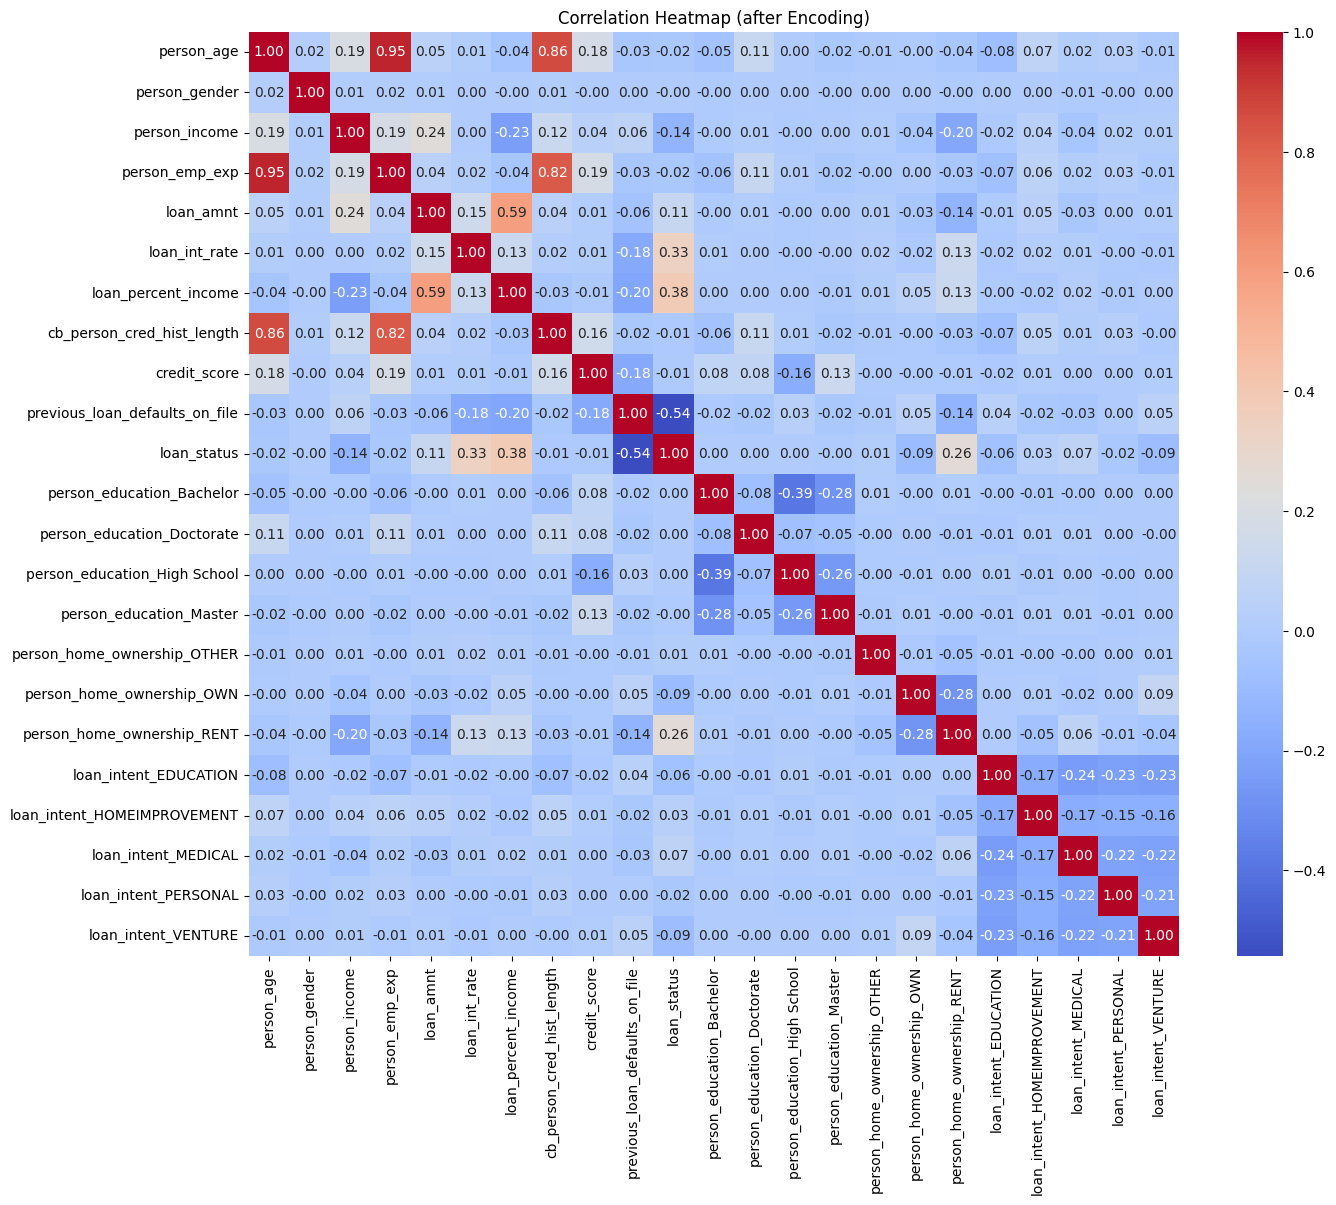

In [26]:
plt.figure(figsize=(15, 12))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Heatmap (after Encoding)")
plt.show()


# Train-Test Split

In [27]:
y = df['loan_status']

X = df.drop('loan_status', axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model Building - Random Forest

In [28]:
rf = RandomForestClassifier(random_state=42,class_weight='balanced', n_estimators=100)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)


# Model Evaluation

In [29]:
rf.score(X_train, y_train)


1.0

In [30]:
rf.score(X_test, y_test)


0.9295555555555556

# Classification Report & Confusion Matrix

In [31]:

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))




Accuracy: 0.9295555555555556

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.98      0.96      6990
           1       0.90      0.77      0.83      2010

    accuracy                           0.93      9000
   macro avg       0.92      0.87      0.89      9000
weighted avg       0.93      0.93      0.93      9000



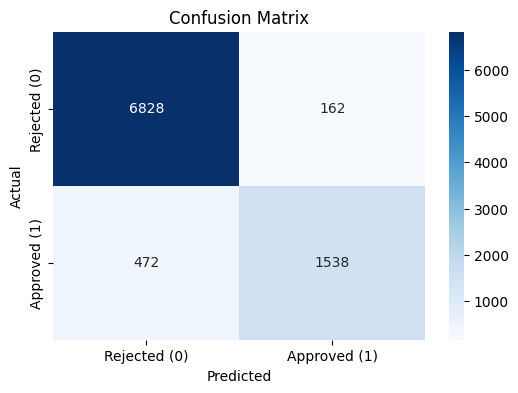

In [32]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Rejected (0)', 'Approved (1)'], yticklabels=['Rejected (0)', 'Approved (1)'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Feature Importance

In [33]:
importances = rf.feature_importances_
feature_names = X.columns

feature_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False)


In [34]:
feature_imp_df.head()

,Feature,Importance
9,previous_loan_defaults_on_file,0.329576
5,loan_int_rate,0.144866
6,loan_percent_income,0.120071
2,person_income,0.114291
4,loan_amnt,0.053526


# Save Model with Pickle

In [35]:
with open('random_forest_model.pkl', 'wb') as file:
    pickle.dump(rf, file)